# Оценка качества модели на тестовой выборке

In [24]:
import os
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, accuracy_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
PATH = './../data/processed/'
files = {
    'customer': 'customer_nodes_testing.p', 
    'event': 'event_table_testing.p', 
    'product': 'product_nodes_testing.p'
}

In [10]:
df_cus = pd.read_pickle(PATH + files['customer'])
df_prt = pd.read_pickle(PATH + files['product'])
df_evt = pd.read_pickle(PATH + files['event'])

df = df_evt.merge(df_cus, how='inner', on='hash(customerId)').merge(df_prt, how='inner', on='hash(variantID)')
df = df[['yearOfBirth', 'isMale', 'shippingCountry', 'premier', 'customerReturnRate', 'productType', 'brandDesc', 'avgGbpPrice', 'avgDiscountValue', 'productReturnRate', 'isReturned']]

## Подгружаем обученную модель

In [14]:
model = CatBoostClassifier()
model.load_model("catboost_model.json", format='json')

In [15]:
X_test = df.drop(columns=['isReturned'])
y_test = df['isReturned']

In [16]:
optimal_threshold = 0.4

In [19]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.80      0.58      0.67    447096
           1       0.70      0.88      0.78    513673

    accuracy                           0.74    960769
   macro avg       0.75      0.73      0.73    960769
weighted avg       0.75      0.74      0.73    960769



In [20]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc

0.8372748408899839

## Делаем итоговую таблицу и графики

Saved predictions to predictions.csv
METRICS SUMMARY
ROC-AUC: 0.8373
Average precision (PR AUC): 0.8609
F1 @ 0.4: 0.7813
Precision: 0.7043, Recall: 0.8774, Accuracy: 0.7375
Confusion matrix:
 [[257848 189248]
 [ 63001 450672]]


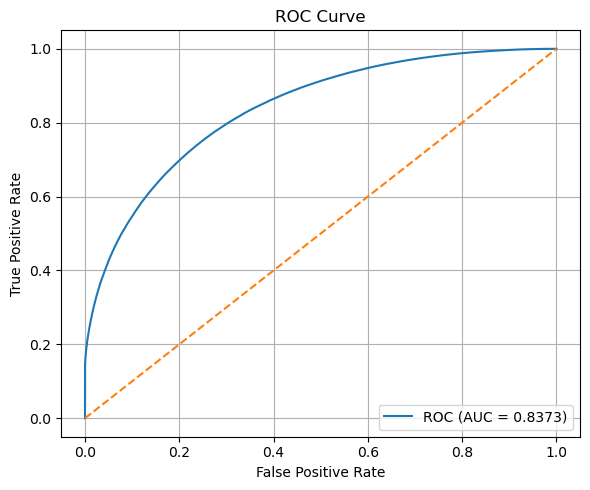

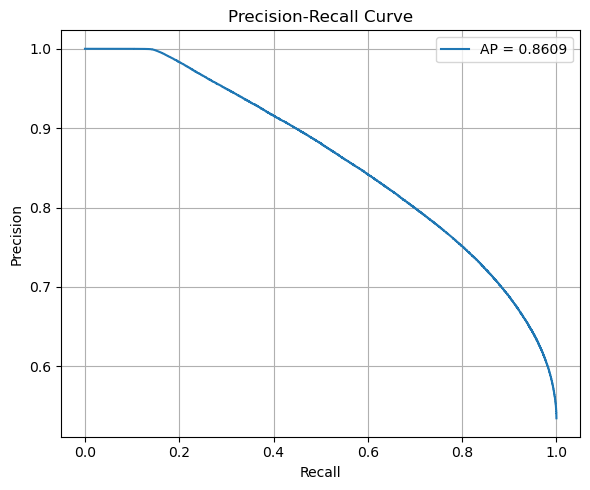

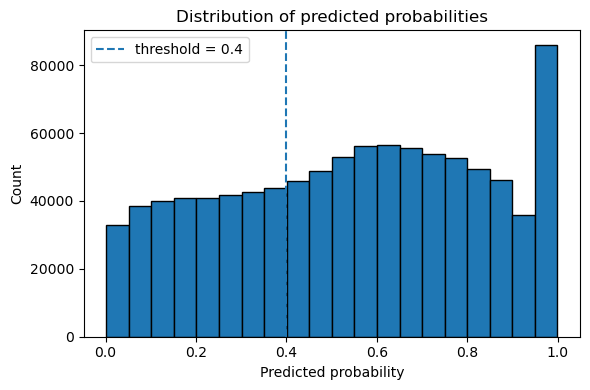

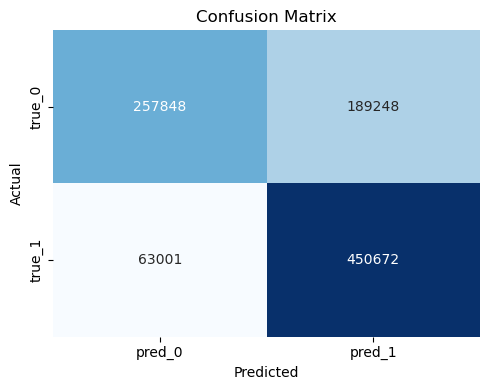

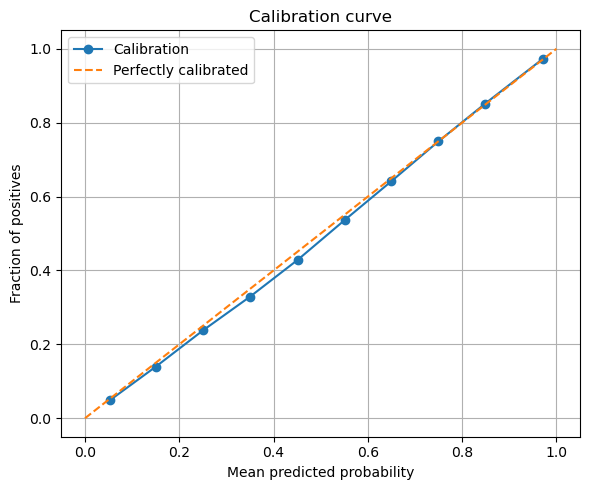

In [26]:
predictions_csv = "predictions.csv"
plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)

predictions_df = X_test.copy()
predictions_df["pred_proba"] = y_pred_proba
predictions_df["pred"] = y_pred_optimal
predictions_df["true"] = y_test.values

# сохранение CSV
predictions_df.to_csv(predictions_csv, index=True)  # index можно убрать, если не нужен
print(f"Saved predictions to {predictions_csv}")

roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred_optimal)
precision = precision_score(y_test, y_pred_optimal)
recall = recall_score(y_test, y_pred_optimal)
accuracy = accuracy_score(y_test, y_pred_optimal)
avg_prec = average_precision_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred_optimal)

metrics = {
    "roc_auc": float(roc_auc),
    "average_precision": float(avg_prec),
    "f1": float(f1),
    "precision": float(precision),
    "recall": float(recall),
    "accuracy": float(accuracy),
    "threshold": float(optimal_threshold),
    "confusion_matrix": cm.tolist()
}

# classification report (строкой)
cls_report = classification_report(y_test, y_pred_optimal, digits=4, output_dict=True)
metrics["classification_report"] = cls_report

# также распечатаем кратко в ноутбуке
print("="*40)
print("METRICS SUMMARY")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average precision (PR AUC): {avg_prec:.4f}")
print(f"F1 @ {optimal_threshold}: {f1:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}")
print("Confusion matrix:\n", cm)
print("="*40)

# ---------- Визуализации ----------

# 1) ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_val:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "roc_curve.png"))
plt.show()

# 2) Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
avg_prec_val = average_precision_score(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"AP = {avg_prec_val:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "precision_recall.png"))
plt.show()

# 3) Гистограмма вероятностей
plt.figure(figsize=(6,4))
plt.hist(y_pred_proba, bins=20, edgecolor='black')
plt.axvline(optimal_threshold, linestyle='--', label=f"threshold = {optimal_threshold}")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Distribution of predicted probabilities")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "proba_histogram.png"))
plt.show()

# 4) Матрица ошибок (heatmap)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["pred_0","pred_1"], yticklabels=["true_0","true_1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "confusion_matrix.png"))
plt.show()

# 5) Калибровочная кривая
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label="Calibration")
plt.plot([0,1],[0,1], linestyle='--', label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "calibration_curve.png"))
plt.show()

### Вывод:

Кривая ROC заметно выше диагонали (AUC > 0.83): модель хорошо отделяет возвраты от покупок при разных порогах и пригодна для ранжирования риска.
